1. Загрузка датасета Iris 

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 加载数据集
file_path = 'iris.data'
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
iris_df = pd.read_csv(file_path, header=None, names=column_names)



Датасет Iris содержит информацию о трех видах ирисов. pairplot из библиотеки seaborn — это идеальный инструмент, чтобы увидеть, как признаки соотносятся друг с другом и насколько хорошо классы разделимы линейно.

2. визуальный анализ (pairplot)

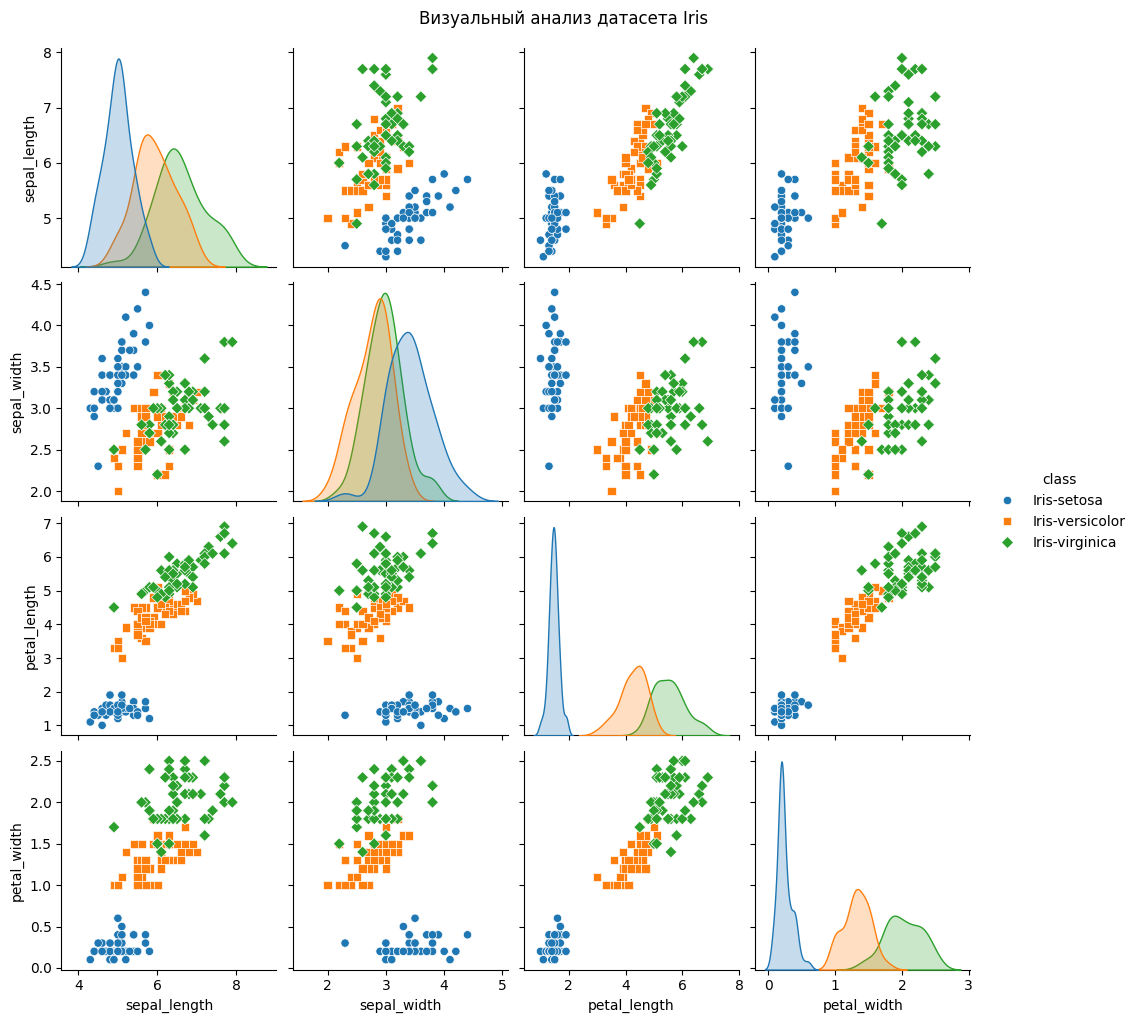

In [20]:
# 2. 绘制 pairplot
sns.pairplot(iris_df, hue='class', markers=["o", "s", "D"])
plt.suptitle('Визуальный анализ датасета Iris', y=1.02)
plt.show()

Можно наглядно сделать вывод: Iris-setosa (обычно это синие точки на рисунке) имеет очень четкие физические границы в пространстве признаков по сравнению с двумя другими типами цветов. Это означает, что это категория «линейно разделима». В то время как точки данных Versicolor и Virginica перекрываются на краях, что указывает на то, что их различие требует чуть более сложной границы принятия решений.

3.Бинарная классификация с помощью LogisticRegression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 过滤数据：只保留 Iris-setosa 和 Iris-versicolor 两个类别
binary_iris = iris_df[iris_df['class'] != 'Iris-virginica']

# 划分特征变量 (X) 和目标变量 (y)
X = binary_iris.drop('class', axis=1)
y = binary_iris['class']

# 生成随机抽样（将数据划分为训练集和测试集）
# test_size=0.2 表示 20% 的数据将用于测试模型
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化并训练逻辑回归模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 在测试集上进行预测
predictions = model.predict(X_test)

# 评估模型性能
print(f"Точность (Accuracy): {accuracy_score(y_test, predictions)}")
print("\nОтчет о классификации:")
print(classification_report(y_test, predictions))

Точность (Accuracy): 1.0

Отчет о классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      1.00      1.00         8

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20



Это доказывает, что модель логистической регрессии показала отличные результаты в задаче классификации этих двух категорий (точность 100%). Это подтверждает наблюдение, которое мы сделали на первом шаге с графиком pairplot: поскольку эти две категории полностью не пересекаются в пространстве признаков, базовый линейный классификатор (логистическая регрессия) может идеально провести разделяющую линию между ними, не прибегая к сложным моделям глубокого обучения или деревьям.

4.Демонстрация переобучения Линейной Регрессии

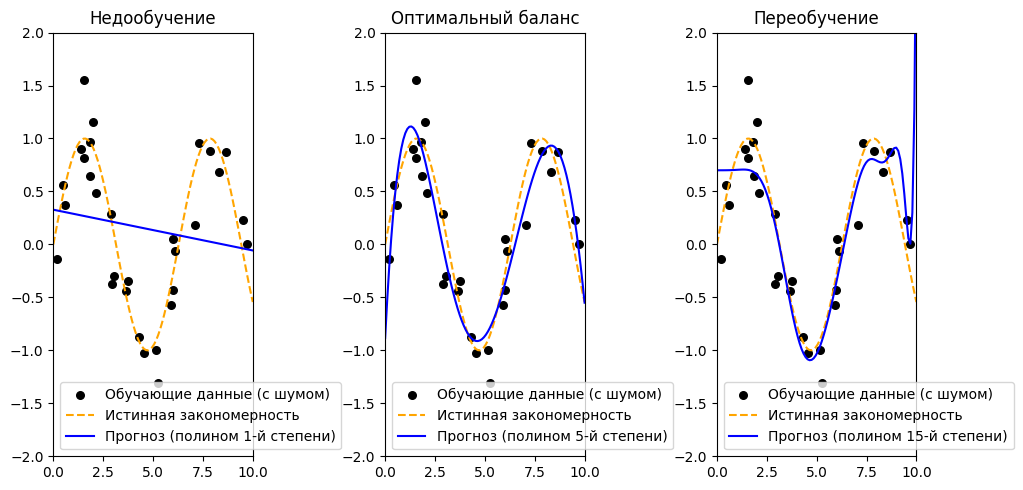

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# 1. 生成带有噪声的非线性数据 (正弦波)
np.random.seed(42)
n_samples = 30
# 随机生成0到10之间的点
X = np.sort(np.random.rand(n_samples)) * 10
# 真实规律是 sin(x)，加上高斯噪声
y = np.sin(X) + np.random.randn(n_samples) * 0.3 

# 用于绘制平滑曲线的 X 值
X_plot = np.linspace(0, 10, 100)
# 真实的底层规律（不带噪声）
y_true = np.sin(X_plot)

# 2. 定义三种模型复杂度 (多项式阶数)
# 1阶=直线(欠拟合)，5阶=曲线(完美平衡)，15阶=极端复杂(过拟合)
degrees = [1, 5, 15] 

# 3. 创建一个 1行3列 的画布，尺寸稍大一些以容纳三张图
plt.figure(figsize=(16, 5))

for i, degree in enumerate(degrees):
    # 选择当前子图
    ax = plt.subplot(1, 5, i + 1)
    
    # 使用 Pipeline 将“多项式特征生成”和“线性回归”组合在一起
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    
    # 训练模型 (注意：sklearn需要二维数组，所以用 X[:, np.newaxis])
    pipeline.fit(X[:, np.newaxis], y)
    
    # 进行预测
    y_plot = pipeline.predict(X_plot[:, np.newaxis])
    
    # 绘制图表
    plt.scatter(X, y, color='black', s=30, label="Обучающие данные (с шумом)")
    plt.plot(X_plot, y_true, color='orange', linestyle='--', label="Истинная закономерность")
    plt.plot(X_plot, y_plot, color='blue', label=f"Прогноз (полином {degree}-й степени)")
    
    plt.xlim((0, 10))
    plt.ylim((-2, 2))
    plt.legend(loc="lower left")
    
    # 根据阶数设置不同的标题
    if degree == 1:
        plt.title(f"Недообучение")
    elif degree == 5:
        plt.title(f"Оптимальный баланс")
    else:
        plt.title(f"Переобучение")

# 自动调整子图间距并展示
plt.tight_layout()
plt.show()

Анализ заключений:

Левая диаграмма (Недообучение / многочлен 1-го порядка - недообучение): синяя линия — это жесткая прямая. Вывод: когда модель слишком простая (пытается описать кривую прямой линией), она не может ни пройти через точки данных, ни соответствовать реальному закономерному поведению, проявляя высокую смещенность (High Bias).

Средняя диаграмма (Оптимальный баланс / многочлен 5-го порядка - идеальный баланс): синяя кривая почти идеально совпадает с желтой пунктирной линией, но не стремится пройти через каждый шумовой точечный сигнал. Вывод: сложность модели подходит идеально, она успешно изучила «суть» данных (синусоидальный закономерность), одновременно игнорируя случайно возникший «шум», обладая наибольшей способностью к обобщению (наиболее точное предсказание новых данных).

Правая диаграмма (Переобучение / многочлен 15-го порядка - сильное переобучение): синяя кривая имеет экстремально искажённую форму «американских горок», чтобы насильно пройти через каждую черную точку, между точками происходят абсурдные взлёты и падения. Вывод: модель чрезмерно сложна, запоминает «случайную ошибку» в данных как абсолютную истину. Хотя ошибка на существующих тренировочных точках равна 0, при встрече с новыми точками предсказания будут крайне неверными, проявляя высокую дисперсию (High Variance).